In [6]:
import pandas as pd
df = pd.read_csv("heart.csv")
print(df.head())
print(df["target"].value_counts())

   age  sex  cp  trestbps  chol  fbs  thalach  exang  oldpeak  ca  target
0   49    0   3       177   150    0       95      0      2.3   0       0
1   56    1   0       124   172    1       86      1      0.5   0       1
2   66    0   3       100   239    0      105      0      1.7   0       0
3   64    0   0       168   222    0       95      1      2.8   0       1
4   60    1   2       153   358    0      147      0      3.2   0       1
1    6
0    3
Name: target, dtype: int64


In [7]:
x = df.drop("target",axis=1)
y = df["target"]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2,random_state = 42)

In [8]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
pred = model.predict(x_test)
print(pred[:10])

[0 0]


In [9]:
from sklearn.metrics import(accuracy_score,confusion_matrix,precision_score,recall_score,f1_score)
acc = accuracy_score(y_test,pred)
cm = confusion_matrix(y_test,pred)
prec = precision_score(y_test,pred)
rec = recall_score(y_test,pred)
f1 = f1_score(y_test,pred)
print(acc,prec,rec,f1)
print(cm)

0.0 0.0 0.0 0.0
[[0 0]
 [2 0]]


C:\Users\ITLAB\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


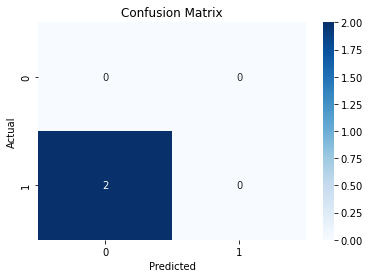

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [11]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
pred_knn = knn.predict(x_test)
print(accuracy_score(y_test,pred_knn))

0.5


In [18]:
for k in [1, 3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train,y_train)
    pred_k = knn.predict(x_test)
    acc_k = accuracy_score(y_test,pred_k)
    print("k=",k,"->Accuracy:",acc_k)

k= 1 ->Accuracy: 0.5
k= 3 ->Accuracy: 0.5
k= 5 ->Accuracy: 0.5
k= 7 ->Accuracy: 1.0
